# Avances del Laboratorio 5

En este notebook se trabaja el dataset **Natural Language Processing with Disaster Tweets** usando Python. El problema consiste en clasificar cada tweet en una de dos clases:

- `1`: el tweet está relacionado con un desastre real.
- `0`: el tweet no describe un desastre real.

El objetivo de este avance es documentar la comprensión inicial del dataset, justificar el preprocesamiento del texto, explorar unigramas y bigramas, y construir un primer modelo preliminar de clasificación.

In [1]:
import os
import re
import string
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Markdown, display
from wordcloud import WordCloud

from sklearn.feature_extraction.text import (
    CountVectorizer,
    ENGLISH_STOP_WORDS,
    TfidfVectorizer,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split

os.environ["MPLCONFIGDIR"] = "/tmp/mplconfig_lab5"
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 220)
pd.set_option("display.max_columns", None)

DATA_PATH = Path("data/train.csv")

def mostrar_markdown(texto):
    display(Markdown(texto))

## Carga del dataset

In [2]:
df = pd.read_csv(DATA_PATH)
df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation orders in California",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,1


In [3]:
df.shape

(7613, 5)

In [4]:
n_filas, n_columnas = df.shape
mostrar_markdown(
    f'''
El dataset contiene **{n_filas} filas** y **{n_columnas} columnas**. Cada fila representa un tweet individual con su texto, un identificador, campos auxiliares como `keyword` y `location`, y la variable objetivo `target`.

La variable objetivo es **`target`**. En este problema, `target = 1` indica que el tweet habla de un desastre real, mientras que `target = 0` indica que usa ese vocabulario en un contexto no literal o no relacionado con un desastre real.
'''
)


El dataset contiene **7613 filas** y **5 columnas**. Cada fila representa un tweet individual con su texto, un identificador, campos auxiliares como `keyword` y `location`, y la variable objetivo `target`.

La variable objetivo es **`target`**. En este problema, `target = 1` indica que el tweet habla de un desastre real, mientras que `target = 0` indica que usa ese vocabulario en un contexto no literal o no relacionado con un desastre real.


## Descripción inicial de los datos

In [5]:
resumen = pd.DataFrame(
    {
        "tipo": df.dtypes.astype(str),
        "no_nulos": df.notna().sum(),
        "faltantes": df.isna().sum(),
        "unicos": df.nunique(),
    }
)
resumen

,tipo,no_nulos,faltantes,unicos
id,int64,7613,0,7613
keyword,object,7552,61,221
location,object,5080,2533,3341
text,object,7613,0,7503
target,int64,7613,0,2


In [6]:
mostrar_markdown(
    f'''
La tabla confirma que `id` funciona como un identificador y no como una variable semántica del tweet. `text` está completo en todo el dataset, lo cual es una buena señal porque es la fuente principal para el modelo.

`keyword` tiene **{int(df["keyword"].isna().sum())} valores faltantes**, una cantidad pequeña en comparación con el total. En cambio, `location` tiene **{int(df["location"].isna().sum())} faltantes**, por lo que su cobertura es bastante menor y desde esta etapa ya parece una columna más ruidosa.

`target` contiene exactamente las dos categorías esperadas, así que no hay indicios de etiquetas fuera del dominio del problema.
'''
)


La tabla confirma que `id` funciona como un identificador y no como una variable semántica del tweet. `text` está completo en todo el dataset, lo cual es una buena señal porque es la fuente principal para el modelo.

`keyword` tiene **61 valores faltantes**, una cantidad pequeña en comparación con el total. En cambio, `location` tiene **2533 faltantes**, por lo que su cobertura es bastante menor y desde esta etapa ya parece una columna más ruidosa.

`target` contiene exactamente las dos categorías esperadas, así que no hay indicios de etiquetas fuera del dominio del problema.


## Calidad de los datos

### Valores faltantes

In [7]:
faltantes = df.isna().sum()
porcentajes_faltantes = (df.isna().mean() * 100).round(2)
pd.DataFrame({"faltantes": faltantes, "porcentaje": porcentajes_faltantes})

,faltantes,porcentaje
id,0,0.00
keyword,61,0.80
location,2533,33.27
text,0,0.00
target,0,0.00


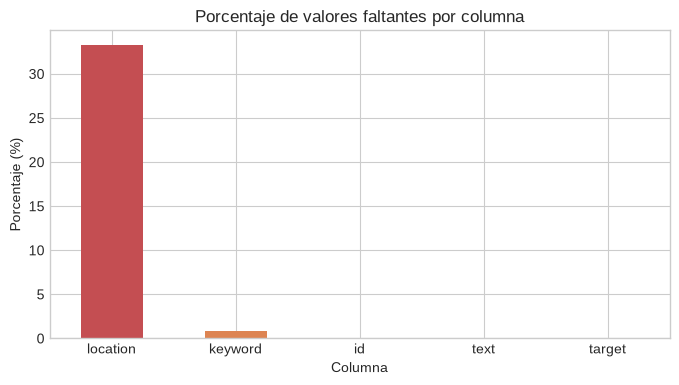

In [8]:
ax = porcentajes_faltantes.sort_values(ascending=False).plot(
    kind="bar",
    figsize=(8, 4),
    color=["#c44e52", "#dd8452", "#55a868", "#4c72b0", "#8172b3"],
    title="Porcentaje de valores faltantes por columna",
)
ax.set_ylabel("Porcentaje (%)")
ax.set_xlabel("Columna")
plt.xticks(rotation=0)
plt.show()

Para este avance no conviene eliminar tweets solo porque `keyword` o `location` estén vacíos. El texto del tweet sigue presente y es la fuente principal de información para la clasificación, así que perder observaciones por columnas auxiliares sería una decisión agresiva.

La decisión será conservar todas las filas, usar `text` como base del análisis y tratar `keyword` y `location` como variables de apoyo para exploración.

### Duplicados

In [9]:
duplicados_completos = int(df.duplicated().sum())
duplicados_texto = int(df["text"].duplicated().sum())

print("Duplicados completos:", duplicados_completos)
print("Textos repetidos:", duplicados_texto)

df.loc[df["text"].duplicated(keep=False), ["text", "target"]].sort_values("text").head(12)

Duplicados completos: 0
Textos repetidos: 110


,text,target
4290,#Allah describes piling up #wealth thinking it would last #forever as the description of the people of #Hellfire in Surah Humaza. #Reflect,0
4299,#Allah describes piling up #wealth thinking it would last #forever as the description of the people of #Hellfire in Surah Humaza. #Reflect,0
4312,#Allah describes piling up #wealth thinking it would last #forever as the description of the people of #Hellfire in Surah Humaza. #Reflect,1
6363,#Bestnaijamade: 16yr old PKK suicide bomber who detonated bomb in ... http://t.co/KSAwlYuX02 bestnaijamade bestnaijamade bestnaijamade beÛ_,1
6373,#Bestnaijamade: 16yr old PKK suicide bomber who detonated bomb in ... http://t.co/KSAwlYuX02 bestnaijamade bestnaijamade bestnaijamade beÛ_,1
6377,#Bestnaijamade: 16yr old PKK suicide bomber who detonated bomb in ... http://t.co/KSAwlYuX02 bestnaijamade bestnaijamade bestnaijamade beÛ_,1
6378,#Bestnaijamade: 16yr old PKK suicide bomber who detonated bomb in ... http://t.co/KSAwlYuX02 bestnaijamade bestnaijamade bestnaijamade beÛ_,1
6392,#Bestnaijamade: 16yr old PKK suicide bomber who detonated bomb in ... http://t.co/KSAwlYuX02 bestnaijamade bestnaijamade bestnaijamade beÛ_,1
6366,#Bestnaijamade: 16yr old PKK suicide bomber who detonated bomb in ... http://t.co/KSAwlYuX02 bestnaijamade bestnaijamade bestnaijamade beÛ_,1
2828,#KCA #VoteJKT48ID 12News: UPDATE: A family of 3 has been displaced after fired damaged housed near 90th and Osborn. Fire extinguished no iÛ_,1


In [10]:
mostrar_markdown(
    f'''
No aparecen filas completamente duplicadas, pero sí hay **{duplicados_texto} textos repetidos**. Como el problema es de clasificación supervisada y no todos los textos repetidos implican un error de captura, en este avance se mantendrán para no alterar artificialmente la distribución del dataset.

Aun así, vale la pena revisarlos en una etapa posterior porque algunos podrían influir en la evaluación si existen versiones muy parecidas entre entrenamiento y prueba.
'''
)


No aparecen filas completamente duplicadas, pero sí hay **110 textos repetidos**. Como el problema es de clasificación supervisada y no todos los textos repetidos implican un error de captura, en este avance se mantendrán para no alterar artificialmente la distribución del dataset.

Aun así, vale la pena revisarlos en una etapa posterior porque algunos podrían influir en la evaluación si existen versiones muy parecidas entre entrenamiento y prueba.


### Distribución de la variable objetivo

In [11]:
distribucion_target = df["target"].value_counts().sort_index()
distribucion_target

target
0    4342
1    3271
Name: count, dtype: int64

In [12]:
porcentajes_target = (df["target"].value_counts(normalize=True).sort_index() * 100).round(2)
porcentajes_target

target
0    57.03
1    42.97
Name: proportion, dtype: float64

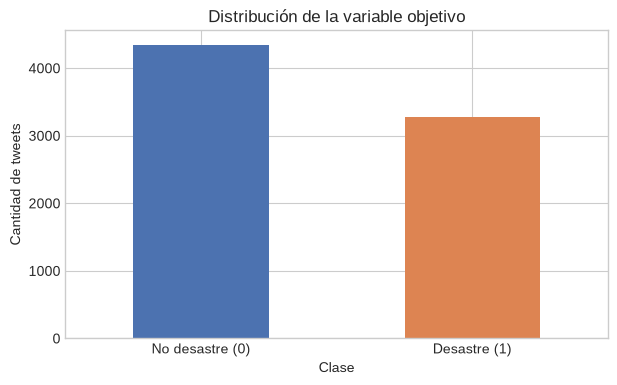

In [13]:
etiquetas = ["No desastre (0)", "Desastre (1)"]
ax = distribucion_target.plot(
    kind="bar",
    figsize=(7, 4),
    color=["#4c72b0", "#dd8452"],
    title="Distribución de la variable objetivo",
)
ax.set_xticklabels(etiquetas, rotation=0)
ax.set_ylabel("Cantidad de tweets")
ax.set_xlabel("Clase")
plt.show()

In [14]:
mostrar_markdown(
    f'''
Hay **{int(distribucion_target.loc[0])} tweets** en la clase `0` y **{int(distribucion_target.loc[1])} tweets** en la clase `1`. En porcentaje, esto equivale a **{porcentajes_target.loc[0]:.2f}%** para no desastre y **{porcentajes_target.loc[1]:.2f}%** para desastre.

Existe un desbalance moderado a favor de la clase `0`, pero no parece extremo. En principio no obliga a aplicar una técnica especial de balanceo en esta línea base, aunque sí conviene vigilar métricas como `recall` y `f1` además de `accuracy`.
'''
)


Hay **4342 tweets** en la clase `0` y **3271 tweets** en la clase `1`. En porcentaje, esto equivale a **57.03%** para no desastre y **42.97%** para desastre.

Existe un desbalance moderado a favor de la clase `0`, pero no parece extremo. En principio no obliga a aplicar una técnica especial de balanceo en esta línea base, aunque sí conviene vigilar métricas como `recall` y `f1` además de `accuracy`.


## Exploración inicial del texto

In [15]:
df["n_caracteres"] = df["text"].str.len()
df["n_palabras_original"] = df["text"].str.split().str.len()
df["n_hashtags"] = df["text"].str.count(r"#\w+")
df["n_menciones"] = df["text"].str.count(r"@\w+")
df["n_urls"] = df["text"].str.count(r"http\S+|www\.\S+")
df["n_numeros"] = df["text"].str.count(r"\b\d+\b")

metricas_texto = (
    df.groupby("target")[
        [
            "n_caracteres",
            "n_palabras_original",
            "n_hashtags",
            "n_menciones",
            "n_urls",
            "n_numeros",
        ]
    ]
    .agg(["mean", "median"])
    .round(2)
)
metricas_texto

n_caracteres        n_palabras_original        n_hashtags         \
               mean median                mean median       mean median   
target                                                                    
0             95.71  101.0               14.70   15.0       0.39    0.0   
1            108.11  115.0               15.17   15.0       0.50    0.0   

       n_menciones        n_urls        n_numeros         
              mean median   mean median      mean median  
target                                                    
0             0.42    0.0   0.51    0.0      0.24    0.0  
1             0.27    0.0   0.77    1.0      0.45    0.0

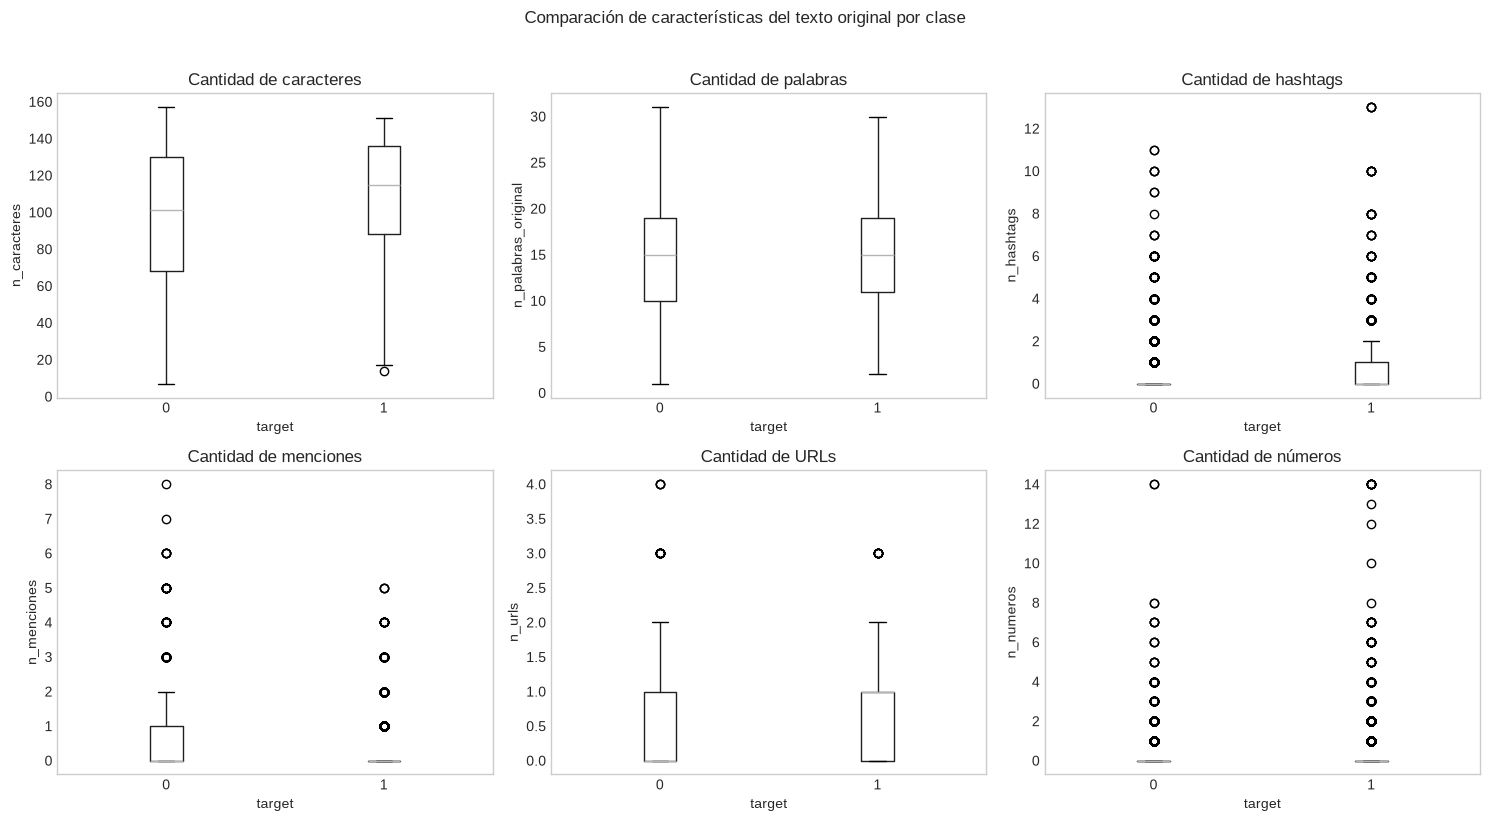

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
variables = [
    ("n_caracteres", "Cantidad de caracteres"),
    ("n_palabras_original", "Cantidad de palabras"),
    ("n_hashtags", "Cantidad de hashtags"),
    ("n_menciones", "Cantidad de menciones"),
    ("n_urls", "Cantidad de URLs"),
    ("n_numeros", "Cantidad de números"),
]

for ax, (columna, titulo) in zip(axes.ravel(), variables):
    df.boxplot(column=columna, by="target", ax=ax, grid=False)
    ax.set_title(titulo)
    ax.set_xlabel("target")
    ax.set_ylabel(columna)

plt.suptitle("Comparación de características del texto original por clase", y=1.02)
plt.tight_layout()
plt.show()

In [17]:
medias = df.groupby("target")[
    ["n_caracteres", "n_palabras_original", "n_hashtags", "n_menciones", "n_urls", "n_numeros"]
].mean().round(2)

mostrar_markdown(
    f'''
Los tweets de desastre tienden a ser un poco más largos: su promedio de caracteres es **{medias.loc[1, "n_caracteres"]}** frente a **{medias.loc[0, "n_caracteres"]}** en la clase no desastre. También muestran ligeramente más palabras por tweet.

La diferencia en URLs, hashtags y menciones existe pero no parece tan fuerte como para separar por sí sola las clases. Eso sugiere que la señal principal seguirá estando en el contenido léxico del texto, no tanto en estos contadores simples.
'''
)


Los tweets de desastre tienden a ser un poco más largos: su promedio de caracteres es **108.11** frente a **95.71** en la clase no desastre. También muestran ligeramente más palabras por tweet.

La diferencia en URLs, hashtags y menciones existe pero no parece tan fuerte como para separar por sí sola las clases. Eso sugiere que la señal principal seguirá estando en el contenido léxico del texto, no tanto en estos contadores simples.


## Diseño del preprocesamiento

El preprocesamiento se diseñará con una meta práctica: conservar la mayor parte del significado útil para clasificación y, al mismo tiempo, reducir ruido que produzca demasiadas variantes irrelevantes.

Las decisiones principales serán:

- convertir a minúsculas para unificar palabras como `Fire`, `fire` y `FIRE`;
- eliminar URLs porque suelen aportar poco contenido semántico directo;
- eliminar menciones `@usuario` para evitar tokens demasiado específicos;
- conservar la palabra del hashtag, eliminando solo el símbolo `#`;
- eliminar signos de puntuación y normalizar espacios;
- mantener números por ahora, porque algunos casos como `911` sí pueden tener relación con emergencias;
- eliminar stopwords en inglés para concentrar la representación en términos más informativos.

En esta etapa no se aplicará stemming ni lematización. Antes de agregar más transformaciones conviene entender bien qué tanto ayudan las decisiones más simples.

In [18]:
numeros_frecuentes = Counter()
for texto in df["text"].astype(str):
    numeros_frecuentes.update(re.findall(r"\b\d+\b", texto))

pd.DataFrame(numeros_frecuentes.most_common(20), columns=["numero", "frecuencia"])

,numero,frecuencia
0,2,215
1,3,133
2,1,115
3,5,96
4,4,94
5,2015,85
6,8,65
7,11,65
8,9,62
9,6,58


In [19]:
df[df["text"].str.contains(r"\b911\b", regex=True, na=False)][["text", "target"]].head(10)

,text,target
2968,@_jeesss_ @Ethereal_7 Hello 911 yeah we have someone drowning here send a medic http://t.co/7GiglwdMhy,1
3162,Came across this fire video not mine..enjoy..#fire #firemen #firetruck #emergency #rescue #911 #summertime #sirensÛ_ http://t.co/hcYAJsAcfJ,1
3202,County 911 Overload Prompts Use of Emergency Plan During July 4 Celebrations http://t.co/HXTUPrA5bc http://t.co/DqxKJibbKy,0
3826,Kirsten Gillibrand http://t.co/amEA3LaMDj Extend Health Care To 911 First RESPONDERS !,1


Aunque muchos números son genéricos y podrían no aportar mucho valor por sí solos, aparecen ejemplos como `911` que sí están asociados a situaciones de emergencia. Por esa razón, en el modelo preliminar se conservarán los números y más adelante se podrá comparar si eliminarlos cambia el desempeño.

Los emojis y símbolos extraños no se modelarán explícitamente en este avance. Es razonable simplificarlos ahora, pero dejando claro que podrían ser útiles si más adelante se hace análisis de sentimiento o una limpieza más fina.

## Limpieza y preprocesamiento

In [20]:
stop_words = set(ENGLISH_STOP_WORDS)

def limpiar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r"http\S+|www\.\S+", " ", texto)
    texto = re.sub(r"@\w+", " ", texto)
    texto = texto.replace("#", "")
    texto = re.sub(r"[^\w\s]", " ", texto)
    texto = re.sub(r"_+", " ", texto)
    tokens = [token for token in texto.split() if token not in stop_words]
    return " ".join(tokens)

df["text_clean"] = df["text"].apply(limpiar_texto)
df[["text", "text_clean"]].head()

,text,text_clean
0,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,deeds reason earthquake allah forgive
1,Forest fire near La Ronge Sask. Canada,forest near la ronge sask canada
2,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected,residents asked shelter place notified officers evacuation shelter place orders expected
3,"13,000 people receive #wildfires evacuation orders in California",13 000 people receive wildfires evacuation orders california
4,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,just got sent photo ruby alaska smoke wildfires pours school


## Validación del preprocesamiento

In [21]:
df[["text", "text_clean"]].sample(10, random_state=42)

,text,text_clean
2644,So you have a new weapon that can cause un-imaginable destruction.,new weapon cause imaginable destruction
2227,The f$&amp;@ing things I do for #GISHWHES Just got soaked in a deluge going for pads and tampons. Thx @mishacollins @/@,f amp things gishwhes just got soaked deluge going pads tampons thx
5448,DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe CoL police can catch a pickpocket in Liverpool Stree... http://t.co/vXIn1gOq4Q,dt rt ûïthe col police catch pickpocket liverpool stree
132,Aftershock back to school kick off was great. I want to thank everyone for making it possible. What a great night.,aftershock school kick great want thank making possible great night
6845,in response to trauma Children of Addicts develop a defensive self - one that decreases vulnerability. (3,response trauma children addicts develop defensive self decreases vulnerability 3
5559,@Calum5SOS you look like you got caught in a rainstorm this is amazing and disgusting at the same time,look like got caught rainstorm amazing disgusting time
1765,my favorite lady came to our volunteer meeting\nhopefully joining her youth collision and i am excite http://t.co/Ij0wQ490cS,favorite lady came volunteer meeting hopefully joining youth collision excite
1817,@brianroemmele UX fail of EMV - people want to insert and remove quickly like a gas pump stripe reader. 1 person told me it crashed the POS,ux fail emv people want insert remove quickly like gas pump stripe reader 1 person told crashed pos
6810,Can't find my ariana grande shirt this is a fucking tragedy,t ariana grande shirt fucking tragedy
4398,The Murderous Story Of AmericaÛªs First Hijacking http://t.co/EYUGk6byxr,murderous story america ûªs hijacking


In [22]:
ejemplos_patrones = df[
    df["text"].str.contains(r"http\S+|www\.\S+|@\w+|#\w+|\b\d+\b|[!?,.;:]", regex=True, na=False)
][["text", "text_clean"]].head(12)
ejemplos_patrones

,text,text_clean
0,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,deeds reason earthquake allah forgive
1,Forest fire near La Ronge Sask. Canada,forest near la ronge sask canada
2,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected,residents asked shelter place notified officers evacuation shelter place orders expected
3,"13,000 people receive #wildfires evacuation orders in California",13 000 people receive wildfires evacuation orders california
4,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,just got sent photo ruby alaska smoke wildfires pours school
5,#RockyFire Update => California Hwy. 20 closed in both directions due to Lake County fire - #CAfire #wildfires,rockyfire update california hwy 20 closed directions lake county cafire wildfires
6,"#flood #disaster Heavy rain causes flash flooding of streets in Manitou, Colorado Springs areas",flood disaster heavy rain causes flash flooding streets manitou colorado springs areas
7,I'm on top of the hill and I can see a fire in the woods...,m hill woods
9,I'm afraid that the tornado is coming to our area...,m afraid tornado coming area
11,Haha South Tampa is getting flooded hah- WAIT A SECOND I LIVE IN SOUTH TAMPA WHAT AM I GONNA DO WHAT AM I GONNA DO FVCK #flooding,haha south tampa getting flooded hah wait second live south tampa gonna gonna fvck flooding


In [23]:
textos_vacios = int((df["text_clean"].str.len() == 0).sum())
print("Textos vacíos después del preprocesamiento:", textos_vacios)

Textos vacíos después del preprocesamiento: 4


In [24]:
mostrar_markdown(
    f'''
La comparación entre `text` y `text_clean` muestra que la limpieza elimina ruido visible como URLs, menciones y puntuación, pero conserva palabras con valor semántico como las que vienen en hashtags. Esto era importante porque en muchos tweets la palabra con `#` sigue describiendo el evento.

Después de procesar todos los registros quedaron **{textos_vacios} textos vacíos**, así que no se observa una pérdida masiva de información por una limpieza demasiado agresiva. La principal limitación es que algunos tokens raros o abreviaturas todavía podrían sobrevivir, pero para una primera línea base esto es aceptable.
'''
)


La comparación entre `text` y `text_clean` muestra que la limpieza elimina ruido visible como URLs, menciones y puntuación, pero conserva palabras con valor semántico como las que vienen en hashtags. Esto era importante porque en muchos tweets la palabra con `#` sigue describiendo el evento.

Después de procesar todos los registros quedaron **4 textos vacíos**, así que no se observa una pérdida masiva de información por una limpieza demasiado agresiva. La principal limitación es que algunos tokens raros o abreviaturas todavía podrían sobrevivir, pero para una primera línea base esto es aceptable.


## Análisis de unigramas

In [25]:
def obtener_ngramas_frecuentes(textos, ngram_range=(1, 1), top_n=20, min_df=1):
    textos = pd.Series(textos).fillna("").astype(str)
    textos = textos[textos.str.strip() != ""]
    vectorizador = CountVectorizer(ngram_range=ngram_range, min_df=min_df)
    matriz = vectorizador.fit_transform(textos)

    frecuencias = np.asarray(matriz.sum(axis=0)).ravel()
    terminos = vectorizador.get_feature_names_out()

    tabla = pd.DataFrame({"termino": terminos, "frecuencia": frecuencias})
    return tabla.sort_values(["frecuencia", "termino"], ascending=[False, True]).head(top_n)

def graficar_top_terminos(tabla, titulo, color):
    tabla_ordenada = tabla.sort_values("frecuencia")
    plt.figure(figsize=(10, 6))
    plt.barh(tabla_ordenada["termino"], tabla_ordenada["frecuencia"], color=color)
    plt.title(titulo)
    plt.xlabel("Frecuencia")
    plt.ylabel("Término")
    plt.tight_layout()
    plt.show()

In [26]:
unigramas_globales = obtener_ngramas_frecuentes(df["text_clean"], ngram_range=(1, 1), top_n=20)
unigramas_globales

,termino,frecuencia
7614,like,348
968,amp,344
7101,just,323
8812,new,226
9599,people,199
8824,news,194
4048,don,190
13726,video,165
3909,disaster,158
4425,emergency,158


In [27]:
uni_no_desastre = obtener_ngramas_frecuentes(
    df.loc[df["target"] == 0, "text_clean"],
    ngram_range=(1, 1),
    top_n=20,
)
uni_desastre = obtener_ngramas_frecuentes(
    df.loc[df["target"] == 1, "text_clean"],
    ngram_range=(1, 1),
    top_n=20,
)

print("Top unigramas - target 0")
display(uni_no_desastre)
print("Top unigramas - target 1")
display(uni_desastre)

Top unigramas - target 0


,termino,frecuencia
5364,like,254
5012,just,234
595,amp,209
6221,new,170
2804,don,138
1282,body,116
9740,video,96
6752,people,94
5513,love,90
2457,day,86


Top unigramas - target 1


,termino,frecuencia
4907,news,137
605,amp,135
2235,disaster,121
1367,california,115
6850,suicide,112
5469,police,109
5331,people,105
4038,killed,95
4260,like,94
3461,hiroshima,92


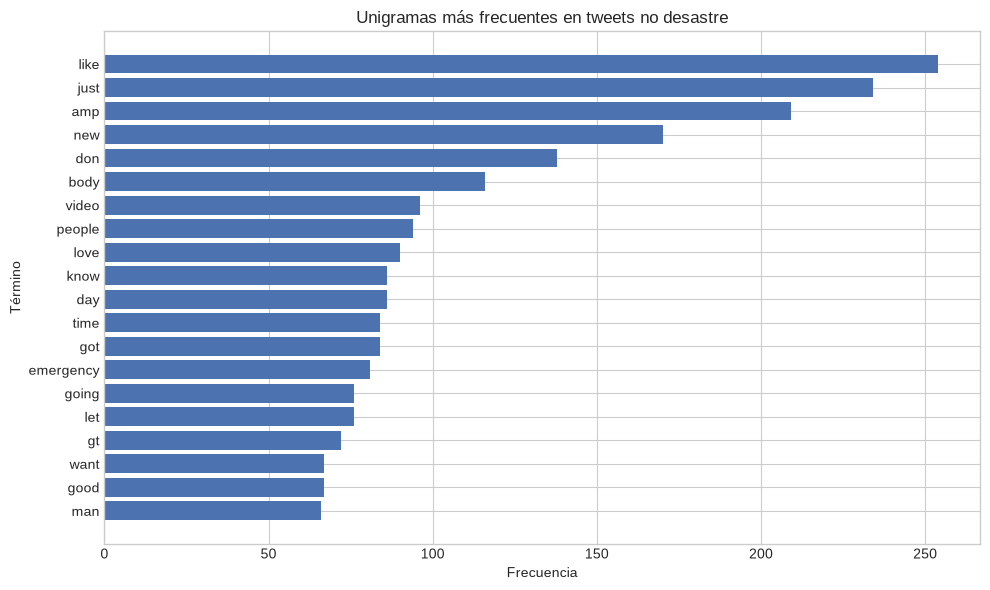

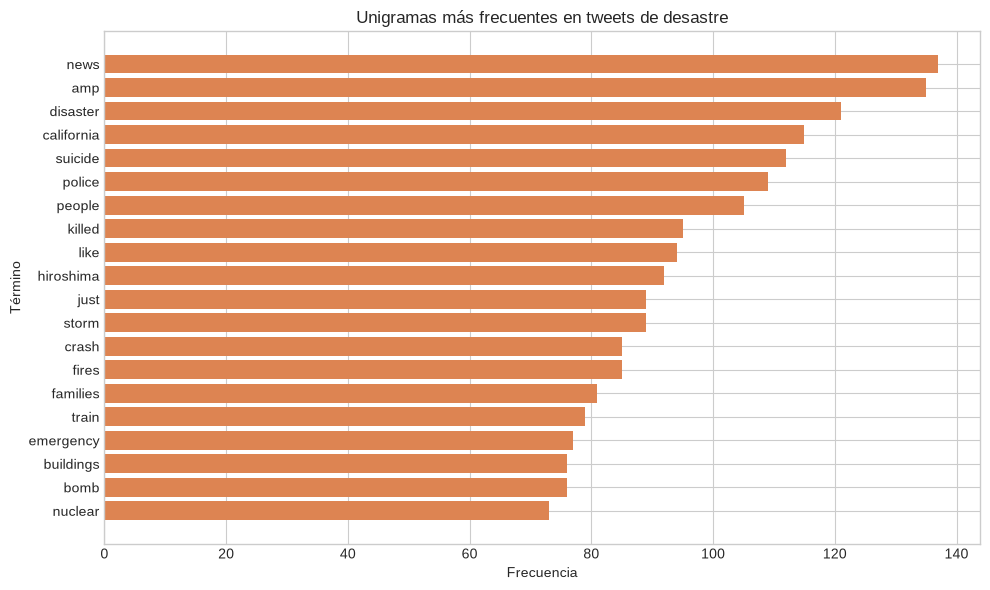

In [28]:
graficar_top_terminos(uni_no_desastre, "Unigramas más frecuentes en tweets no desastre", "#4c72b0")
graficar_top_terminos(uni_desastre, "Unigramas más frecuentes en tweets de desastre", "#dd8452")

## Comparación de unigramas

En esta sección interesa más la utilidad de las palabras para separar clases que la frecuencia aislada. Por eso la lectura debe centrarse en qué términos parecen describir eventos reales, cuáles se usan en sentido figurado y cuáles aparecen tanto en una clase como en la otra.

In [29]:
terminos_comunes = sorted(set(uni_no_desastre["termino"]).intersection(set(uni_desastre["termino"])))
mostrar_markdown(
    f'''
En los tweets de desastre suelen aparecer términos directamente ligados a eventos físicos, daños o emergencias, mientras que en la otra categoría aparecen varias palabras que pueden usar el vocabulario de desastre de forma metafórica o en contextos cotidianos.

Entre los unigramas compartidos por ambos grupos aparecen: **{", ".join(terminos_comunes[:10])}**. Esto es importante porque muestra que varias palabras frecuentes no bastan por sí solas para decidir la clase.

Justamente por eso los términos más prometedores para separar categorías no son solo palabras sueltas muy comunes, sino combinaciones o contextos donde palabras como `fire`, `storm`, `crash` o `emergency` se usen con un significado claramente literal.
'''
)


En los tweets de desastre suelen aparecer términos directamente ligados a eventos físicos, daños o emergencias, mientras que en la otra categoría aparecen varias palabras que pueden usar el vocabulario de desastre de forma metafórica o en contextos cotidianos.

Entre los unigramas compartidos por ambos grupos aparecen: **amp, emergency, just, like, people**. Esto es importante porque muestra que varias palabras frecuentes no bastan por sí solas para decidir la clase.

Justamente por eso los términos más prometedores para separar categorías no son solo palabras sueltas muy comunes, sino combinaciones o contextos donde palabras como `fire`, `storm`, `crash` o `emergency` se usen con un significado claramente literal.


## Nube de palabras

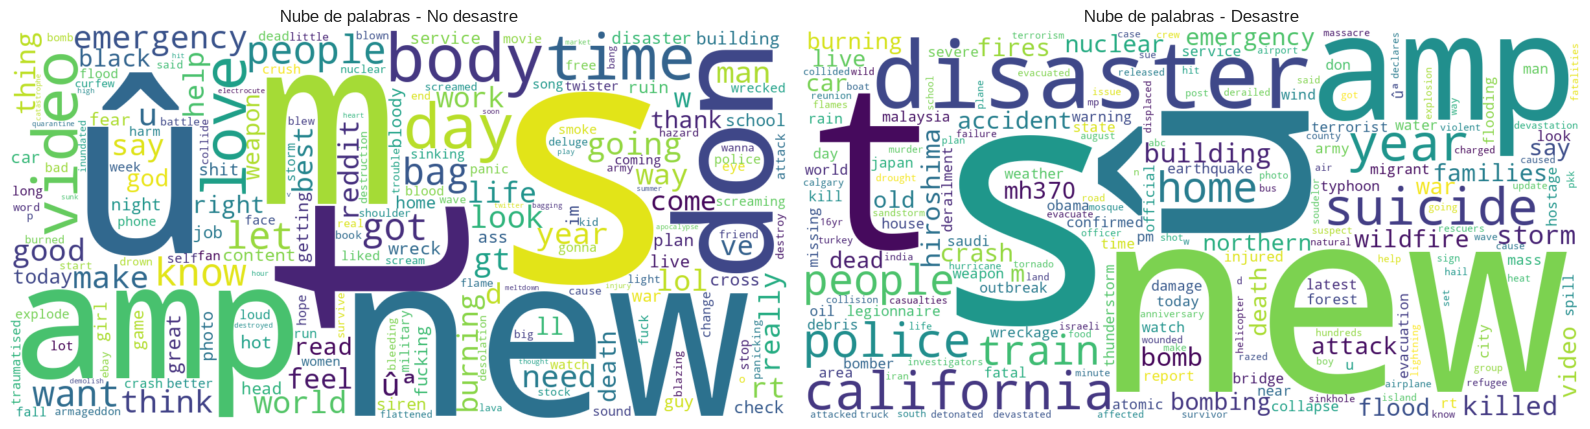

In [30]:
texto_no_desastre = " ".join(df.loc[df["target"] == 0, "text_clean"])
texto_desastre = " ".join(df.loc[df["target"] == 1, "text_clean"])

wc_no = WordCloud(width=1200, height=600, background_color="white", collocations=False).generate(texto_no_desastre)
wc_si = WordCloud(width=1200, height=600, background_color="white", collocations=False).generate(texto_desastre)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(wc_no, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Nube de palabras - No desastre")
axes[1].imshow(wc_si, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Nube de palabras - Desastre")
plt.tight_layout()
plt.show()

La nube de palabras no reemplaza las tablas de frecuencia, pero ayuda a identificar rápidamente qué vocabulario domina en cada grupo. Si una palabra aparece grande en ambas nubes, eso sugiere ambigüedad; si aparece fuerte solo en una, puede ser una señal útil para el clasificador.

## Análisis de bigramas

In [31]:
bigramas_globales = obtener_ngramas_frecuentes(df["text_clean"], ngram_range=(2, 2), top_n=20)
bigramas_no_desastre = obtener_ngramas_frecuentes(
    df.loc[df["target"] == 0, "text_clean"],
    ngram_range=(2, 2),
    top_n=20,
)
bigramas_desastre = obtener_ngramas_frecuentes(
    df.loc[df["target"] == 1, "text_clean"],
    ngram_range=(2, 2),
    top_n=20,
)

print("Top bigramas globales")
display(bigramas_globales)
print("Top bigramas - target 0")
display(bigramas_no_desastre)
print("Top bigramas - target 1")
display(bigramas_desastre)

Top bigramas globales


,termino,frecuencia
6062,burning buildings,60
35586,suicide bomber,59
22368,liked video,41
26248,northern california,41
9282,cross body,40
26742,oil spill,39
35588,suicide bombing,36
6370,california wildfire,34
41739,year old,34
22978,looks like,33


Top bigramas - target 0


,termino,frecuencia
5253,cross body,39
13235,liked video,34
9964,gt gt,30
2948,body bag,27
2950,body bagging,24
3467,burning buildings,23
2951,body bags,22
13656,looks like,21
18004,reddit quarantine,21
4945,content policy,20


Top bigramas - target 1


,termino,frecuencia
15675,suicide bomber,59
11607,northern california,41
11847,oil spill,38
2817,burning buildings,37
15677,suicide bombing,35
2989,california wildfire,34
668,70 years,30
2445,bomber detonated,30
3993,confirmed mh370,29
8201,homes razed,29


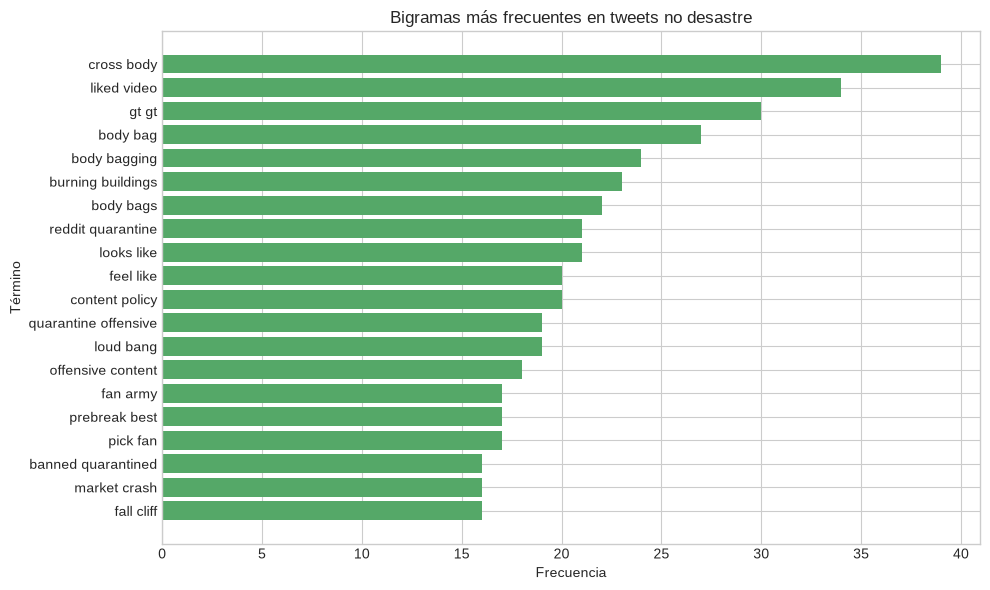

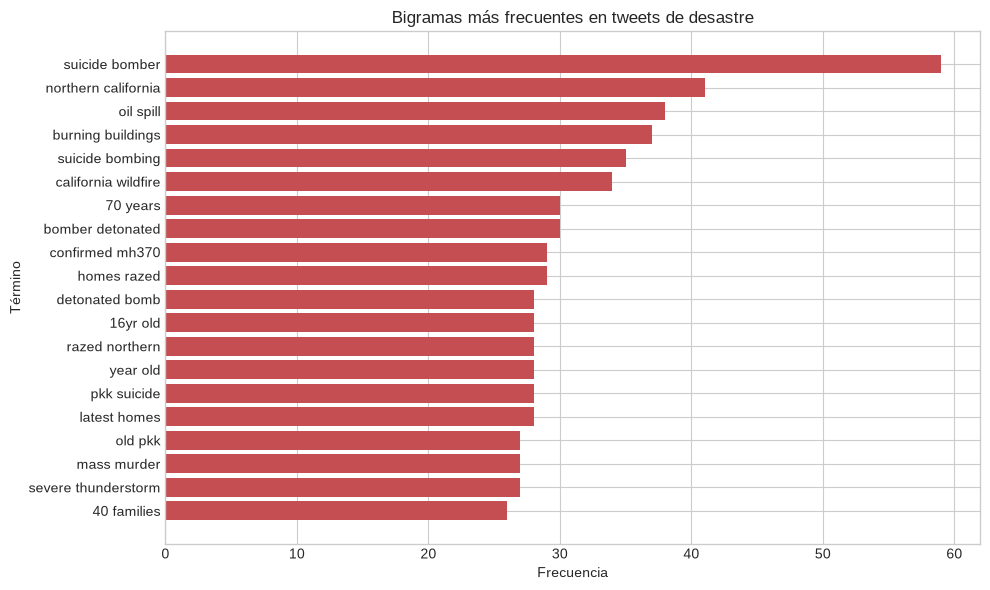

In [32]:
graficar_top_terminos(bigramas_no_desastre, "Bigramas más frecuentes en tweets no desastre", "#55a868")
graficar_top_terminos(bigramas_desastre, "Bigramas más frecuentes en tweets de desastre", "#c44e52")

## Comparación de bigramas

Los bigramas permiten capturar una parte del contexto que los unigramas pierden. En un problema como este eso es valioso, porque varias palabras de desastre también se usan en bromas, música, videojuegos o expresiones figurativas.

In [33]:
mostrar_markdown(
    '''
Si aparecen expresiones como `forest fire`, `suicide bombing`, `oil spill` o combinaciones similares, el contexto ya es mucho más específico que una palabra aislada. Por eso los bigramas pueden ayudar a distinguir mejor entre un uso literal y un uso figurado del mismo vocabulario.

También es posible encontrar bigramas ambiguos. Cuando eso pase, la conclusión no debería ser que los bigramas no sirven, sino que probablemente conviene combinarlos con unigramas en lugar de usarlos solos.
'''
)


Si aparecen expresiones como `forest fire`, `suicide bombing`, `oil spill` o combinaciones similares, el contexto ya es mucho más específico que una palabra aislada. Por eso los bigramas pueden ayudar a distinguir mejor entre un uso literal y un uso figurado del mismo vocabulario.

También es posible encontrar bigramas ambiguos. Cuando eso pase, la conclusión no debería ser que los bigramas no sirven, sino que probablemente conviene combinarlos con unigramas en lugar de usarlos solos.


## Consideración de trigramas

In [34]:
trigramas_desastre = obtener_ngramas_frecuentes(
    df.loc[df["target"] == 1, "text_clean"],
    ngram_range=(3, 3),
    top_n=15,
)
trigramas_desastre

,termino,frecuencia
14967,suicide bomber detonated,30
11109,northern california wildfire,29
2381,bomber detonated bomb,28
7862,homes razed northern,28
9162,latest homes razed,28
12008,pkk suicide bomber,28
276,16yr old pkk,27
11413,old pkk suicide,27
12698,razed northern california,27
556,40 families affected,26


In [35]:
mostrar_markdown(
    '''
Esta prueba breve sirve para revisar si los trigramas aportan frases realmente útiles o si su frecuencia ya cae demasiado. En datasets de tweets, que son textos cortos, es normal que los trigramas aparezcan menos y que muchos queden demasiado dispersos.

Si las expresiones observadas son informativas pero poco repetidas, lo más razonable es dejar los trigramas como una posibilidad futura, no como prioridad del modelo preliminar.
'''
)


Esta prueba breve sirve para revisar si los trigramas aportan frases realmente útiles o si su frecuencia ya cae demasiado. En datasets de tweets, que son textos cortos, es normal que los trigramas aparezcan menos y que muchos queden demasiado dispersos.

Si las expresiones observadas son informativas pero poco repetidas, lo más razonable es dejar los trigramas como una posibilidad futura, no como prioridad del modelo preliminar.


## Exploración de `keyword`

In [36]:
df["keyword"].value_counts().head(20)

keyword
fatalities     45
deluge         42
armageddon     42
damage         41
body%20bags    41
harm           41
sinking        41
evacuate       40
outbreak       40
fear           40
siren          40
windstorm      40
collided       40
twister        40
hellfire       39
famine         39
flames         39
weapon         39
wreckage       39
sunk           39
Name: count, dtype: int64

In [37]:
keyword_stats = (
    df.groupby("keyword")["target"]
    .agg(["count", "mean"])
    .sort_values(["count", "mean"], ascending=[False, False])
)
keyword_stats.head(20)

,count,mean
keyword,,
fatalities,45,0.577778
deluge,42,0.142857
armageddon,42,0.119048
damage,41,0.463415
sinking,41,0.195122
harm,41,0.097561
body%20bags,41,0.024390
outbreak,40,0.975000
evacuate,40,0.625000


In [38]:
pd.crosstab(df["keyword"], df["target"]).head(20)

target,0,1
keyword,,
ablaze,23,13
accident,11,24
aftershock,34,0
airplane%20accident,5,30
ambulance,18,20
annihilated,23,11
annihilation,19,10
apocalypse,23,9
armageddon,37,5


`keyword` parece una variable interesante porque resume temas explícitos del tweet, pero no está libre de ruido. Algunas keywords estarán muy asociadas a desastres reales y otras aparecerán tanto en contextos literales como figurados.

Para este avance se analizará como apoyo interpretativo, pero no se forzará todavía dentro del modelo preliminar. Primero conviene consolidar una línea base centrada en el texto limpio del tweet.

## Exploración de `location`

In [39]:
df["location"].value_counts().head(20)

location
USA                104
New York            71
United States       50
London              45
Canada              29
Nigeria             28
UK                  27
Los Angeles, CA     26
India               24
Mumbai              22
Washington, DC      21
Kenya               20
Worldwide           19
Chicago, IL         18
Australia           18
California          17
California, USA     15
New York, NY        15
Everywhere          15
San Francisco       14
Name: count, dtype: int64

La columna `location` contiene texto libre y no está normalizada. En este tipo de datos es común encontrar ciudades escritas de varias formas, países, abreviaturas, ubicaciones ficticias e incluso frases que no son ubicaciones reales.

Por esa mezcla y por la gran cantidad de faltantes, en el modelo preliminar no se utilizará `location`. Incorporarla bien exigiría una limpieza adicional que no es prioritaria en esta etapa.

## Preparación para modelado

In [40]:
X = df["text_clean"]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Tamaño entrenamiento:", X_train.shape[0])
print("Tamaño prueba:", X_test.shape[0])

Tamaño entrenamiento: 6090
Tamaño prueba: 1523


La separación entrenamiento-prueba permite estimar qué tan bien generaliza el modelo con datos no vistos. Aquí se usa el 80% para entrenamiento y el 20% para prueba.

Se utiliza `stratify=y` para conservar aproximadamente la misma proporción de clases en ambos conjuntos, y `random_state=42` para que el experimento sea reproducible.

## Modelo preliminar de clasificación

Como línea base se utilizará **Regresión Logística** sobre una representación **TF-IDF** con unigramas y bigramas. Esta elección es adecuada porque TF-IDF transforma palabras y combinaciones de palabras en características numéricas dispersas, y la regresión logística suele funcionar bien en clasificación de texto por su simplicidad, velocidad e interpretabilidad.

El vectorizador se ajustará únicamente con `X_train` para evitar fuga de información desde el conjunto de prueba.

In [41]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

modelo = LogisticRegression(
    max_iter=1000,
    random_state=42,
)

modelo.fit(X_train_tfidf, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

## Evaluación preliminar

In [42]:
y_pred = modelo.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1:", round(f1, 4))

Accuracy: 0.8234
Precision: 0.8519
Recall: 0.7125
F1: 0.776


In [43]:
print(classification_report(y_test, y_pred, target_names=["No desastre", "Desastre"]))

              precision    recall  f1-score   support

 No desastre       0.81      0.91      0.85       869
    Desastre       0.85      0.71      0.78       654

    accuracy                           0.82      1523
   macro avg       0.83      0.81      0.82      1523
weighted avg       0.83      0.82      0.82      1523



## Matriz de confusión

In [44]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[788,  81],
       [188, 466]])

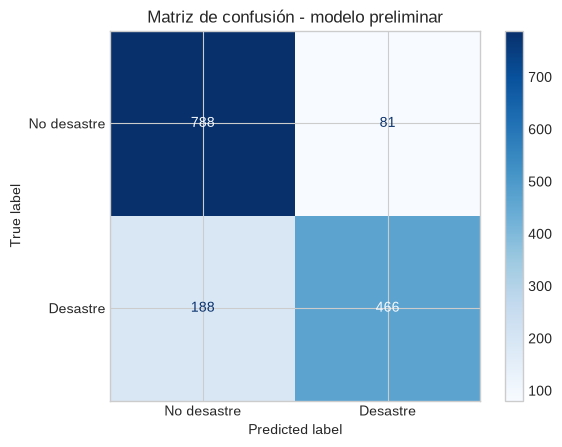

In [45]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No desastre", "Desastre"],
    cmap="Blues",
)
plt.title("Matriz de confusión - modelo preliminar")
plt.show()

In [46]:
tn, fp, fn, tp = cm.ravel()
mostrar_markdown(
    f'''
La matriz de confusión contiene **{tn} verdaderos negativos**, **{fp} falsos positivos**, **{fn} falsos negativos** y **{tp} verdaderos positivos**.

Los falsos negativos merecen atención especial porque representan tweets de desastres reales que el modelo no detectó. En una continuación del laboratorio será importante revisar si esos errores están relacionados con contexto ambiguo, sarcasmo, mensajes demasiado cortos o información que no se capta bien con una bolsa de palabras.
'''
)


La matriz de confusión contiene **788 verdaderos negativos**, **81 falsos positivos**, **188 falsos negativos** y **466 verdaderos positivos**.

Los falsos negativos merecen atención especial porque representan tweets de desastres reales que el modelo no detectó. En una continuación del laboratorio será importante revisar si esos errores están relacionados con contexto ambiguo, sarcasmo, mensajes demasiado cortos o información que no se capta bien con una bolsa de palabras.


## Comparación rápida: unigramas vs unigramas + bigramas

In [47]:
def evaluar_representacion(ngram_range):
    vectorizador = TfidfVectorizer(
        ngram_range=ngram_range,
        min_df=2,
        max_df=0.95,
    )
    X_train_vec = vectorizador.fit_transform(X_train)
    X_test_vec = vectorizador.transform(X_test)

    clasificador = LogisticRegression(max_iter=1000, random_state=42)
    clasificador.fit(X_train_vec, y_train)
    pred = clasificador.predict(X_test_vec)

    return {
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
    }

resultados_modelos = pd.DataFrame(
    {
        "Unigramas": evaluar_representacion((1, 1)),
        "Unigramas + bigramas": evaluar_representacion((1, 2)),
    }
).T.round(4)

resultados_modelos

,Accuracy,Precision,Recall,F1
Unigramas,0.8227,0.8516,0.7110,0.775
Unigramas + bigramas,0.8234,0.8519,0.7125,0.776


In [48]:
mejor_repr = resultados_modelos["F1"].idxmax()
diferencia_f1 = resultados_modelos.loc["Unigramas + bigramas", "F1"] - resultados_modelos.loc["Unigramas", "F1"]
metrica_mayor_cambio = (resultados_modelos.loc["Unigramas + bigramas"] - resultados_modelos.loc["Unigramas"]).abs().idxmax()

mostrar_markdown(
    f'''
La representación con mejor `F1` en esta comparación fue **{mejor_repr}**. La diferencia de `F1` entre usar solo unigramas y usar unigramas con bigramas fue de **{diferencia_f1:.4f}**.

La métrica con mayor cambio absoluto fue **{metrica_mayor_cambio}**. Con base en esta prueba rápida, la decisión para continuar el laboratorio será conservar la representación que ofrezca el mejor equilibrio entre precisión y recuperación.
'''
)


La representación con mejor `F1` en esta comparación fue **Unigramas + bigramas**. La diferencia de `F1` entre usar solo unigramas y usar unigramas con bigramas fue de **0.0010**.

La métrica con mayor cambio absoluto fue **Recall**. Con base en esta prueba rápida, la decisión para continuar el laboratorio será conservar la representación que ofrezca el mejor equilibrio entre precisión y recuperación.


## Palabras importantes para la clasificación

In [49]:
feature_names = tfidf.get_feature_names_out()
coeficientes = modelo.coef_[0]

importancia = pd.DataFrame(
    {
        "termino": feature_names,
        "coeficiente": coeficientes,
    }
)

top_desastre = importancia.sort_values("coeficiente", ascending=False).head(20)
top_no_desastre = importancia.sort_values("coeficiente", ascending=True).head(20)

print("Términos más asociados con desastre (target = 1)")
display(top_desastre)
print("Términos más asociados con no desastre (target = 0)")
display(top_no_desastre)

Términos más asociados con desastre (target = 1)


,termino,coeficiente
3908,hiroshima,3.320117
1418,california,2.770174
3182,fires,2.503039
1324,buildings,2.492954
4504,killed,2.482000
8846,wildfire,2.248523
7698,storm,2.205927
6230,police,2.096814
2650,earthquake,2.089747
7798,suicide,2.084619


Términos más asociados con no desastre (target = 0)


,termino,coeficiente
4949,love,-2.011510
5561,new,-1.870246
4723,let,-1.582747
3738,harm,-1.541723
6962,ruin,-1.540275
1115,bloody,-1.515602
8994,wrecked,-1.488333
2936,explode,-1.465956
1153,body,-1.415729
1095,blew,-1.412299


En regresión logística, coeficientes positivos altos favorecen la predicción de `target = 1`, mientras que coeficientes negativos favorecen `target = 0`. Esto no implica causalidad, pero sí ayuda a entender qué términos está usando el modelo como señales principales.

## Errores del modelo preliminar

In [50]:
errores = pd.DataFrame(
    {
        "texto": X_test,
        "real": y_test,
        "predicho": y_pred,
    }
)
errores = errores[errores["real"] != errores["predicho"]]
errores.sample(min(10, len(errores)), random_state=42)

,texto,real,predicho
719,stab promise ll bleeding,1,0
3256,raheelsharif manifesting right man helm save sinking ship engulfed dark stormy tidal sea,1,0
5902,sandstorm,0,1
7489,wreck edmund fitzgerald,1,0
5038,oso washington mudslide response interview ûò 1,1,0
6585,feel pain survivors look period absurd human history satire indistinguishable reality,1,0
2962,family mourns drowning superhero toddler rare epilepsy bradley diebold suffered hundreds epileptic û,0,1
2675,apollo brown detonate ft m o p fiya,1,0
5069,books flight burma country enduring political unrest natural disaster wonder cheap ay,1,0
1350,m battling monsters m pulling burning buildings say ll come,0,1


Esta muestra de errores sirve para buscar patrones. Si aparecen sarcasmo, ambigüedad, referencias a noticias sin suficiente contexto o expresiones figurativas, eso explicaría por qué una representación basada en n-gramas todavía se equivoca.

También es una buena forma de revisar si el preprocesamiento eliminó algo útil o si algunas combinaciones de palabras todavía no están siendo bien capturadas.

## Conclusiones de los avances

In [51]:
mejor_fila = resultados_modelos["F1"].idxmax()
mostrar_markdown(
    f'''
En esta etapa se observó que el dataset tiene **{n_filas} tweets** con una estructura simple, donde `text` es la fuente principal de información y `target` distingue entre desastre real y uso no literal del vocabulario. Los valores faltantes se concentran sobre todo en `location`, mientras que `text` está completo y `keyword` solo presenta una cantidad pequeña de ausencias.

La variable objetivo muestra un desbalance moderado, no extremo, por lo que una línea base sin técnicas especiales sigue siendo razonable. El preprocesamiento se centró en minúsculas, eliminación de URLs y menciones, conservación del contenido de hashtags, limpieza de puntuación, eliminación de stopwords y normalización de espacios. Los números se conservaron porque algunos ejemplos, como `911`, sí pueden tener valor semántico.

En el análisis exploratorio, los unigramas ayudaron a identificar vocabulario frecuente de cada clase, pero también mostraron ambigüedad entre palabras compartidas. Los bigramas aportaron más contexto y resultan prometedores para distinguir mejor entre uso literal y figurado. Por eso se probó una representación TF-IDF con unigramas y bigramas para el modelo preliminar.

El algoritmo entrenado fue **Regresión Logística**, una línea base interpretable y apropiada para datos de texto dispersos. En la evaluación preliminar se obtuvo **Accuracy = {accuracy:.4f}**, **Precision = {precision:.4f}**, **Recall = {recall:.4f}** y **F1 = {f1:.4f}** con la configuración principal. En la comparación rápida de representaciones, la mejor alternativa según `F1` fue **{mejor_fila}**.

Los errores revisados sugieren que todavía hay casos ambiguos, dependientes de contexto o difíciles de resolver con palabras aisladas. En la continuación del laboratorio valdrá la pena profundizar en ajustes de representación, analizar con más cuidado los errores y evaluar si variables auxiliares como `keyword` pueden aportar información adicional.
'''
)


En esta etapa se observó que el dataset tiene **7613 tweets** con una estructura simple, donde `text` es la fuente principal de información y `target` distingue entre desastre real y uso no literal del vocabulario. Los valores faltantes se concentran sobre todo en `location`, mientras que `text` está completo y `keyword` solo presenta una cantidad pequeña de ausencias.

La variable objetivo muestra un desbalance moderado, no extremo, por lo que una línea base sin técnicas especiales sigue siendo razonable. El preprocesamiento se centró en minúsculas, eliminación de URLs y menciones, conservación del contenido de hashtags, limpieza de puntuación, eliminación de stopwords y normalización de espacios. Los números se conservaron porque algunos ejemplos, como `911`, sí pueden tener valor semántico.

En el análisis exploratorio, los unigramas ayudaron a identificar vocabulario frecuente de cada clase, pero también mostraron ambigüedad entre palabras compartidas. Los bigramas aportaron más contexto y resultan prometedores para distinguir mejor entre uso literal y figurado. Por eso se probó una representación TF-IDF con unigramas y bigramas para el modelo preliminar.

El algoritmo entrenado fue **Regresión Logística**, una línea base interpretable y apropiada para datos de texto dispersos. En la evaluación preliminar se obtuvo **Accuracy = 0.8234**, **Precision = 0.8519**, **Recall = 0.7125** y **F1 = 0.7760** con la configuración principal. En la comparación rápida de representaciones, la mejor alternativa según `F1` fue **Unigramas + bigramas**.

Los errores revisados sugieren que todavía hay casos ambiguos, dependientes de contexto o difíciles de resolver con palabras aisladas. En la continuación del laboratorio valdrá la pena profundizar en ajustes de representación, analizar con más cuidado los errores y evaluar si variables auxiliares como `keyword` pueden aportar información adicional.
